<a href="https://colab.research.google.com/github/Atanga-Theresa/Internship/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Price Prediction

This notebook performs Exploratory Data Analysis (EDA) and initial feature engineering on a housing dataset to understand the factors influencing housing prices. The process includes:

1.  **Data Loading and Initial Inspection**: Loading the dataset and examining its structure, data types, and dimensions.
2.  **Data Quality Assessment**: Checking for missing values and duplicate entries to ensure data integrity.
3.  **Univariate Analysis**: Analyzing the distribution of individual features (both numerical and categorical) to understand their characteristics.
4.  **Bivariate Analysis**: Investigating relationships between `price` and other features using scatter plots, bar plots, and box plots.
5.  **Categorical Feature Encoding**: Converting binary categorical variables (`yes`/`no`) to numerical (1/0) and applying one-hot encoding to multi-class categorical features (`furnishingstatus`).
6.  **Correlation Analysis**: Calculating and visualizing the correlation matrix of all numerical features, including the newly encoded categorical variables, to identify strong predictors of housing prices.

The insights gained from this EDA will be crucial for selecting appropriate features and building robust machine learning models for housing price prediction.

In [ ]:
#import all relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files


In [ ]:
Housing = pd.read_csv("/content/Housing.csv")

In [ ]:
# Displaying first 10 rows of the dataset
Housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# Checking data structure
Housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
Housing.shape #545 rows and 13 columns

(545, 13)

In [ ]:
# Checking data types for columns
Housing.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [ ]:
# Checking for missing values
Housing.isnull().sum() #No nulls found

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
#Checking for duplicates
Housing.duplicated() #No duplicates found

,0
0,False
1,False
2,False
3,False
4,False
...,...
540,False
541,False
542,False
543,False


In [ ]:
Housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# Correct Data Types
Housing["furnishingstatus"] = Housing["furnishingstatus"].astype("category")
Housing["mainroad"] = Housing["mainroad"].astype("category")
Housing["guestroom"] = Housing["guestroom"].astype("category")
Housing["basement"] = Housing["basement"].astype("category")
Housing["hotwaterheating"] = Housing["hotwaterheating"].astype("category")
Housing["airconditioning"] = Housing["airconditioning"].astype("category")
Housing["prefarea"] = Housing["prefarea"].astype("category")


In [ ]:
#Verify Data Quality
Housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


In [ ]:
# Google Colab runs in a cloud environment and doesn't have direct access to local computer's file system.
# This saves the file to the Colab environment's temporary storage. To get that file onto desktop, should be downloaded
#try:
    # Housing.to_csv('Cleaned_Housing.csv', index=False)
    # print('Dataset successfully exported to Cleaned_Housing.csv')
# except Exception as e:
    # print(f'Error exporting dataset: {e}')

In [ ]:
# This will prompt a download of 'Cleaned_Housing.csv' to local machine
#files.download('Cleaned_Housing.csv')

Exploratory Data Analysis (EDA)

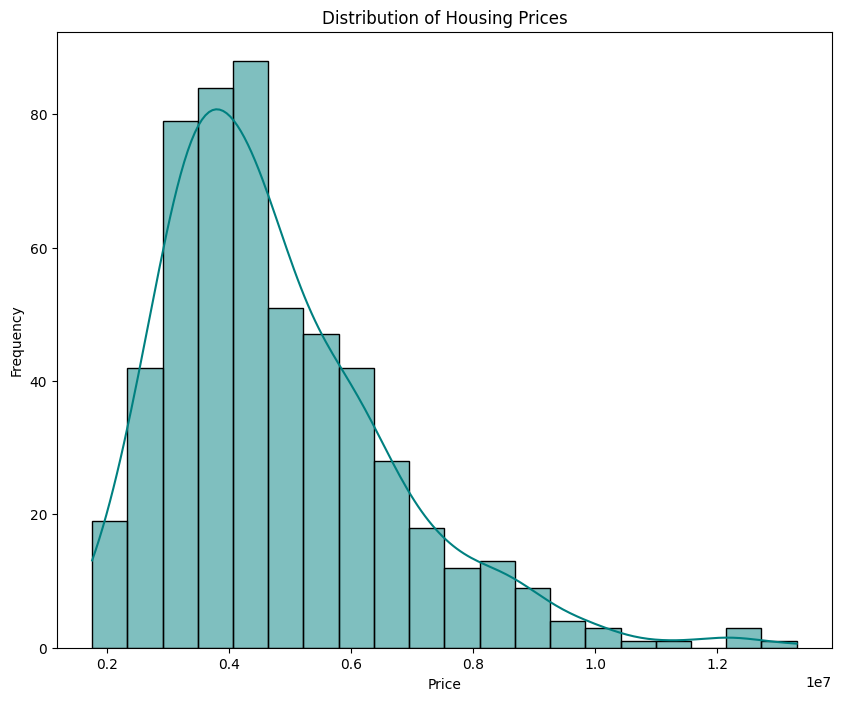

In [ ]:
#Univariate Analysis
plt.figure(figsize=(10,8))
sns.histplot(Housing["price"], bins=20, kde=True, color="teal")
plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

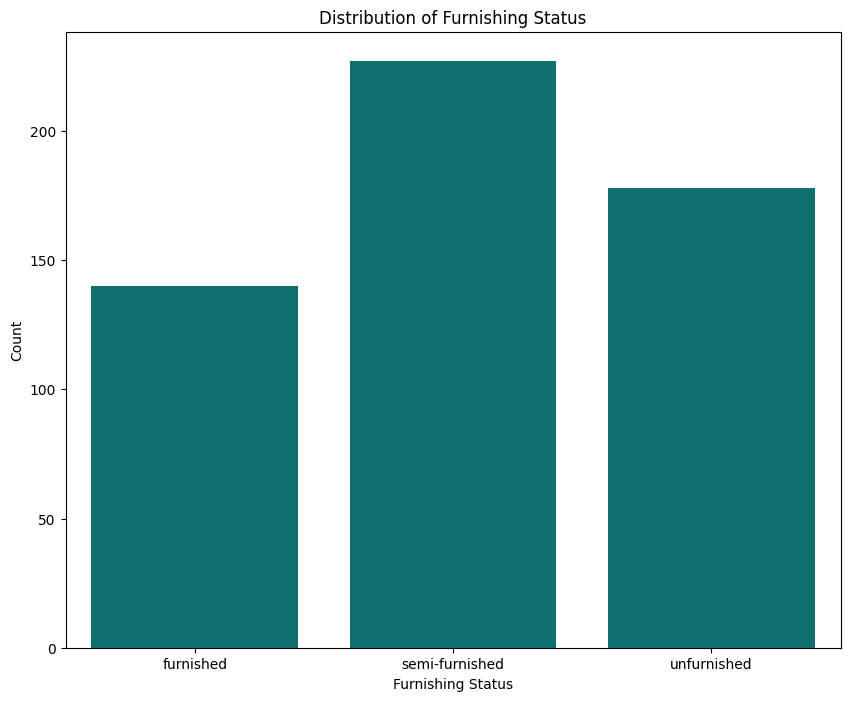

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="furnishingstatus", data=Housing, color="teal")
plt.title("Distribution of Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Count")
plt.show()


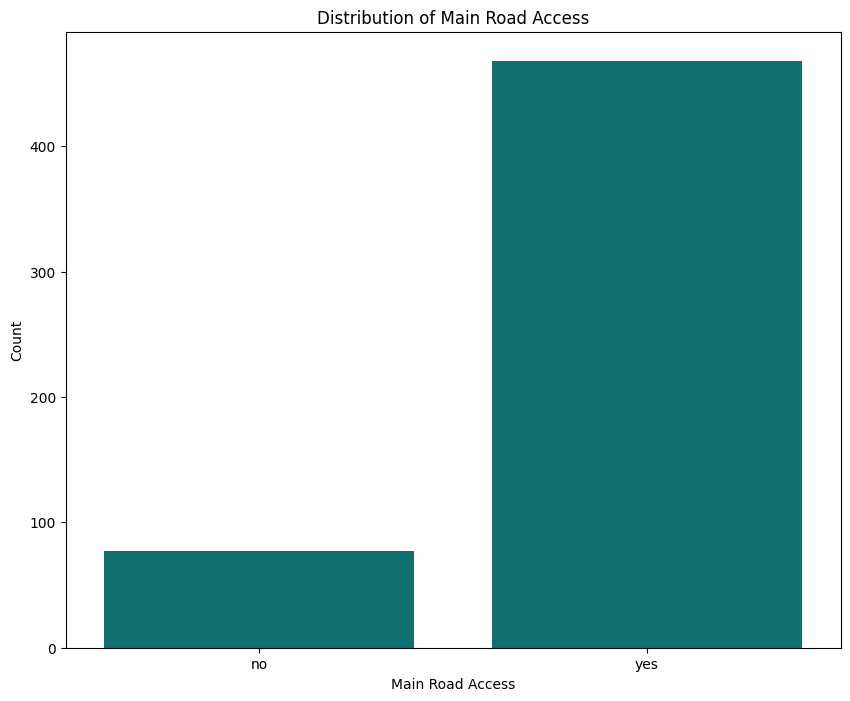

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="mainroad", data=Housing,color="teal")
plt.title("Distribution of Main Road Access")
plt.xlabel("Main Road Access")
plt.ylabel("Count")
plt.show()

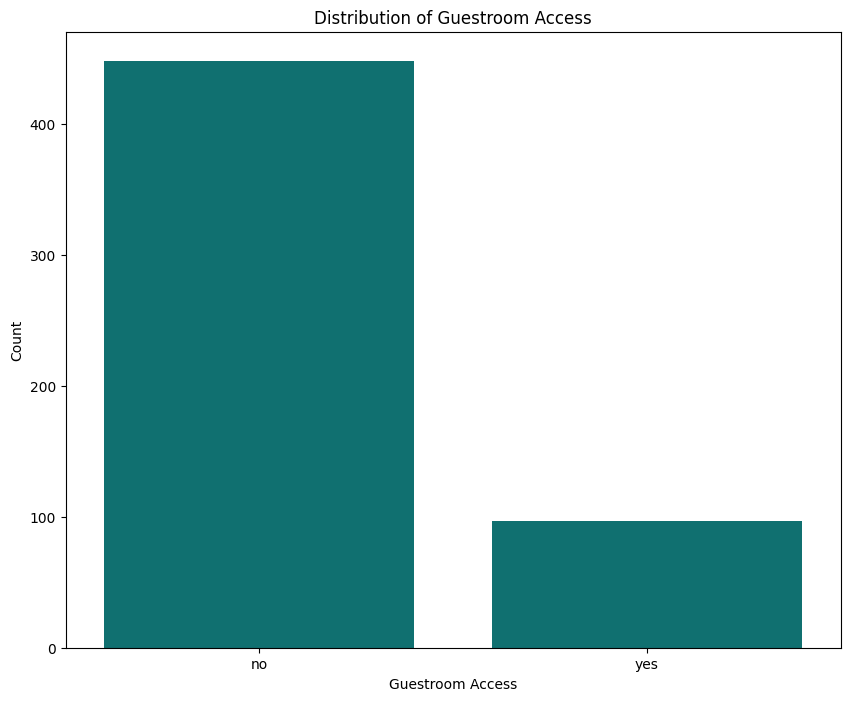

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="guestroom", data=Housing, color="teal")
plt.title("Distribution of Guestroom Access")
plt.xlabel("Guestroom Access")
plt.ylabel("Count")
plt.show()

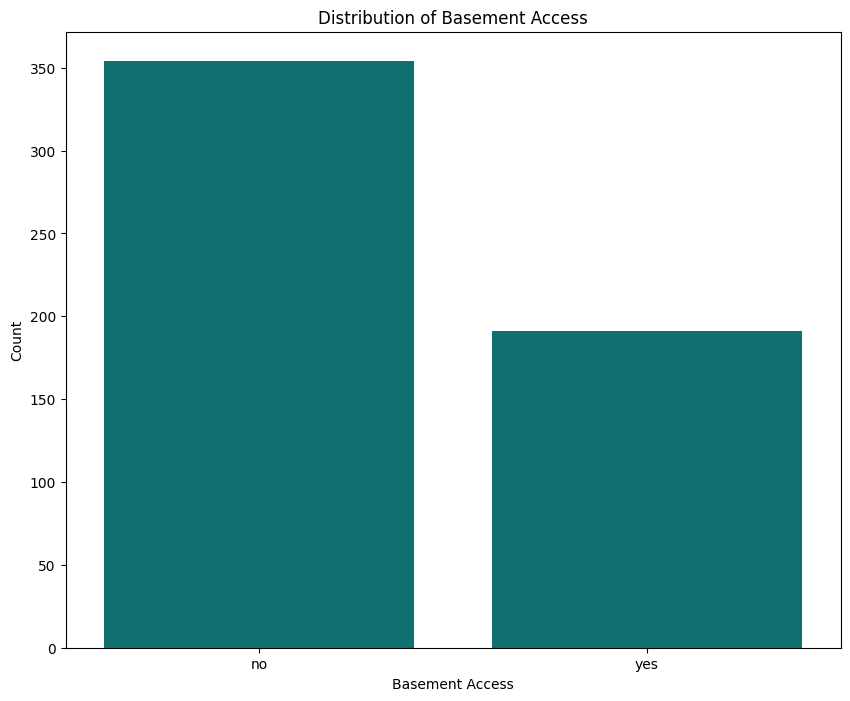

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="basement", data=Housing, color="teal")
plt.title("Distribution of Basement Access")
plt.xlabel("Basement Access")
plt.ylabel("Count")
plt.show()

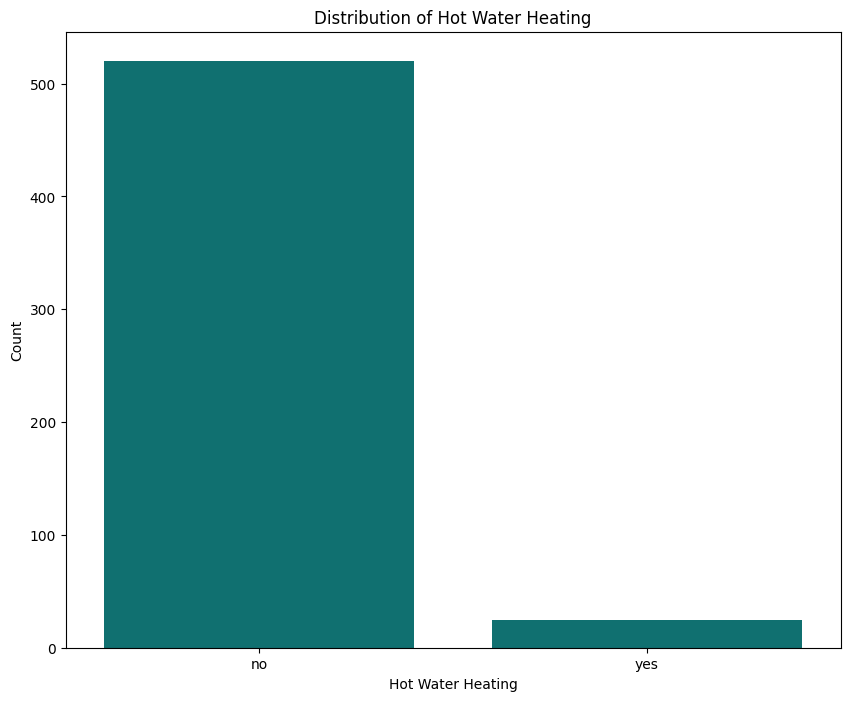

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="hotwaterheating", data=Housing, color="teal")
plt.title("Distribution of Hot Water Heating")
plt.xlabel("Hot Water Heating")
plt.ylabel("Count")
plt.show()

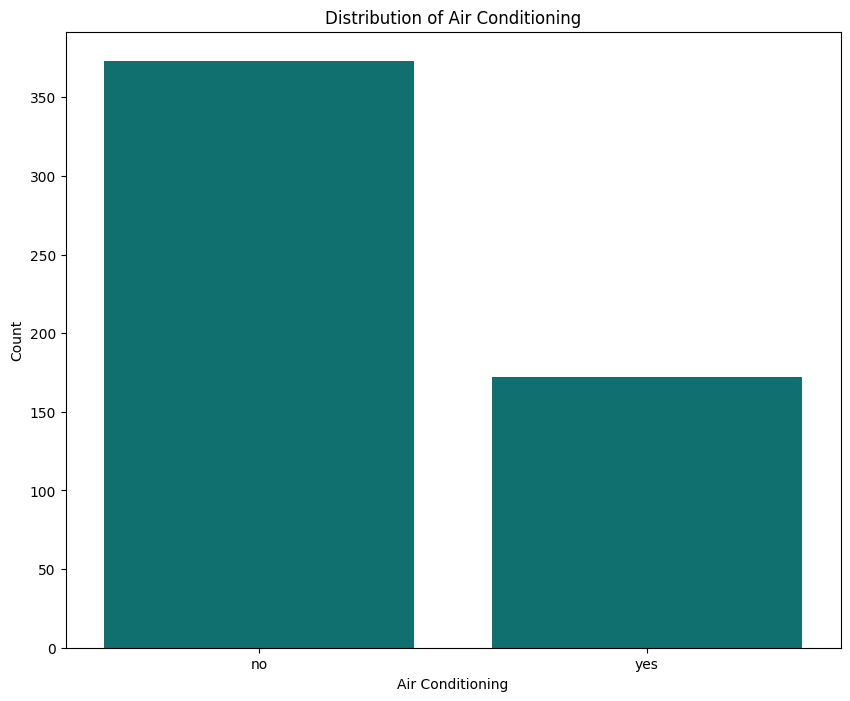

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="airconditioning", data=Housing, color="teal")
plt.title("Distribution of Air Conditioning")
plt.xlabel("Air Conditioning")
plt.ylabel("Count")
plt.show()

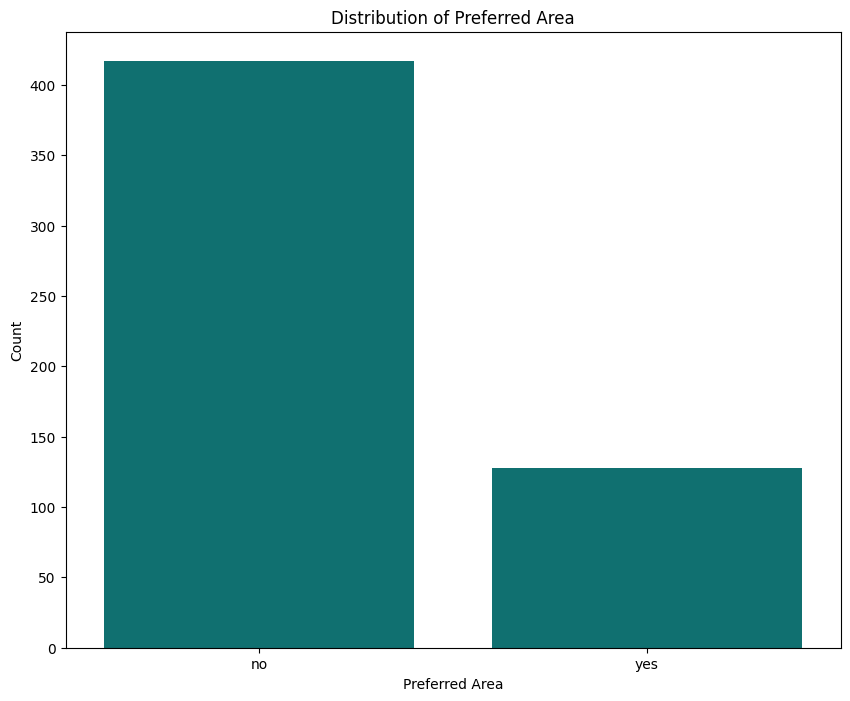

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="prefarea", data=Housing, color="teal")
plt.title("Distribution of Preferred Area")
plt.xlabel("Preferred Area")
plt.ylabel("Count")
plt.show()

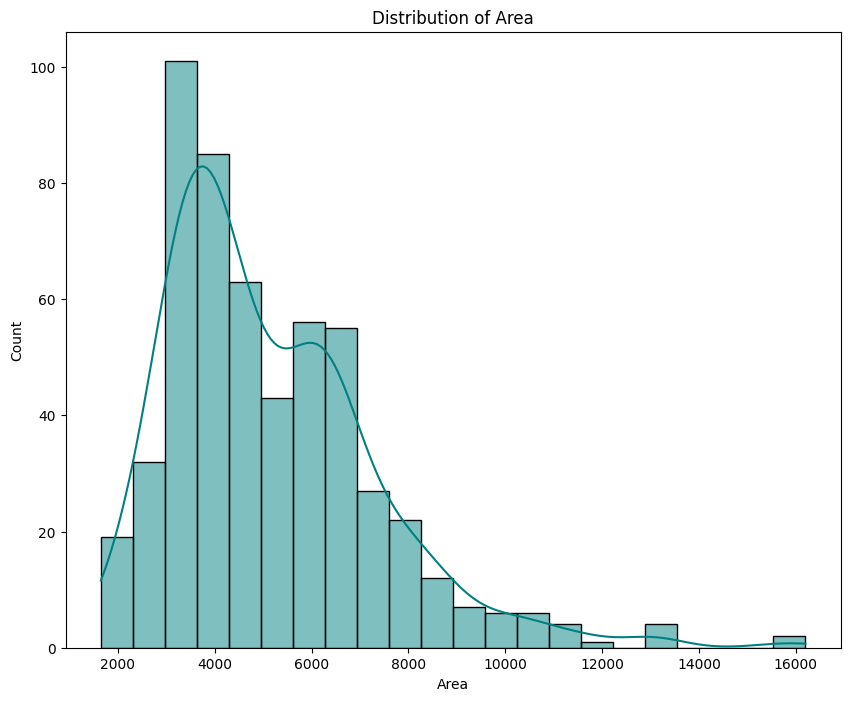

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(x="area", data=Housing, kde=True, color="teal")
plt.title("Distribution of Area")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()

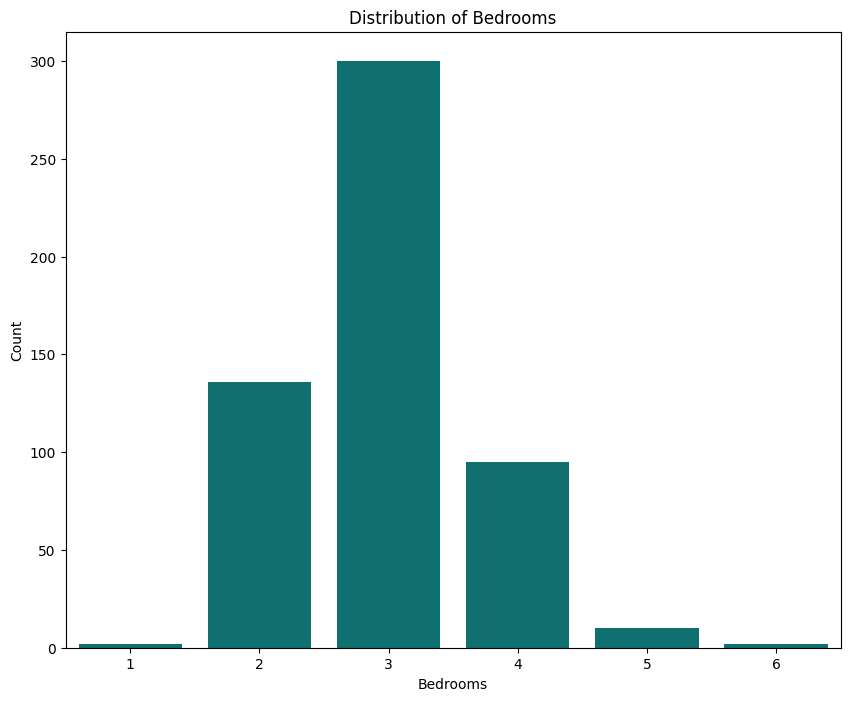

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="bedrooms", data=Housing,color="teal")
plt.title("Distribution of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

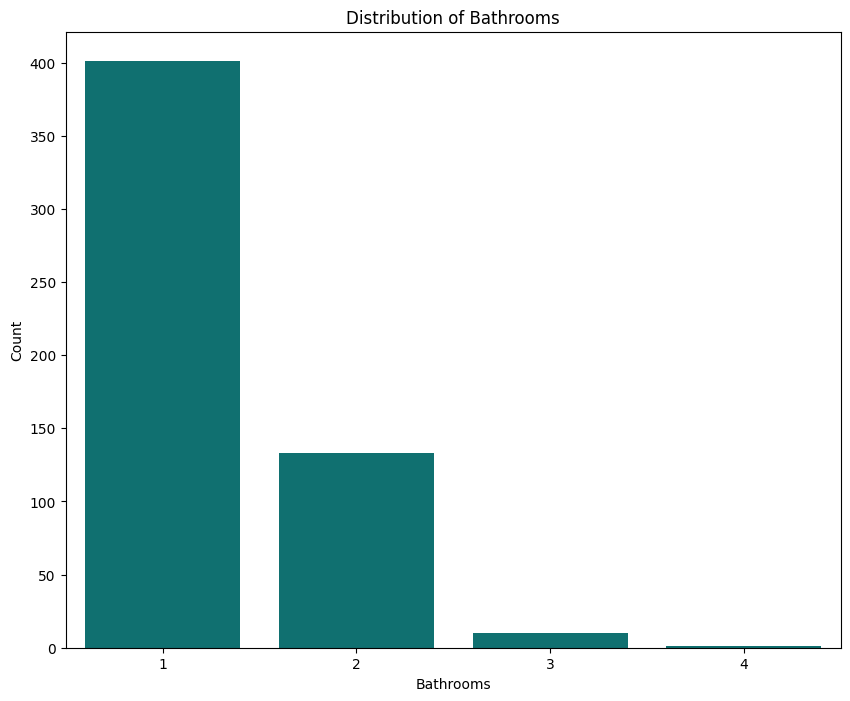

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="bathrooms", data=Housing, color="teal")
plt.title("Distribution of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.show()

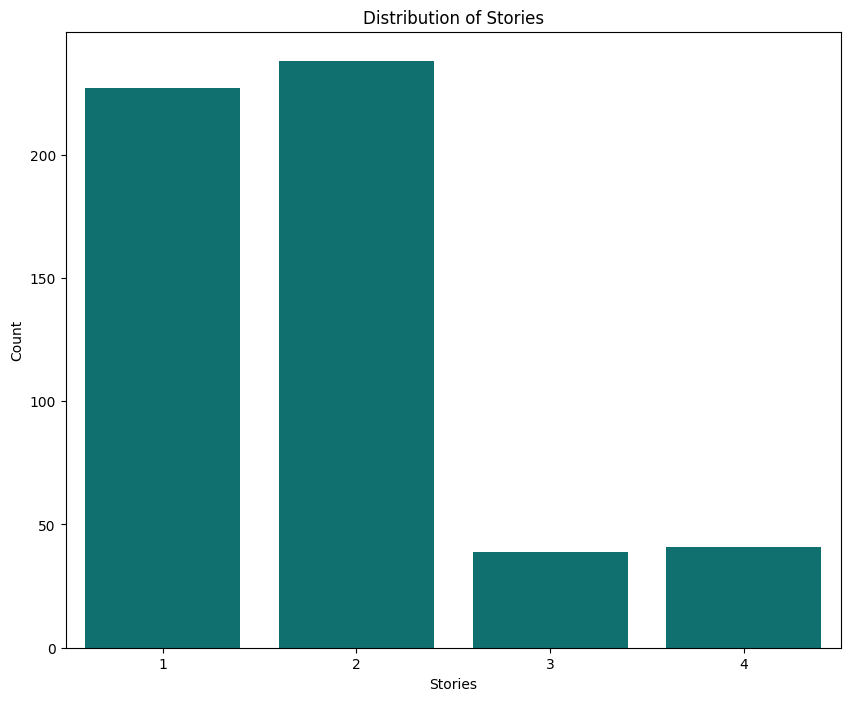

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="stories", data=Housing, color="teal")
plt.title("Distribution of Stories")
plt.xlabel("Stories")
plt.ylabel("Count")
plt.show()

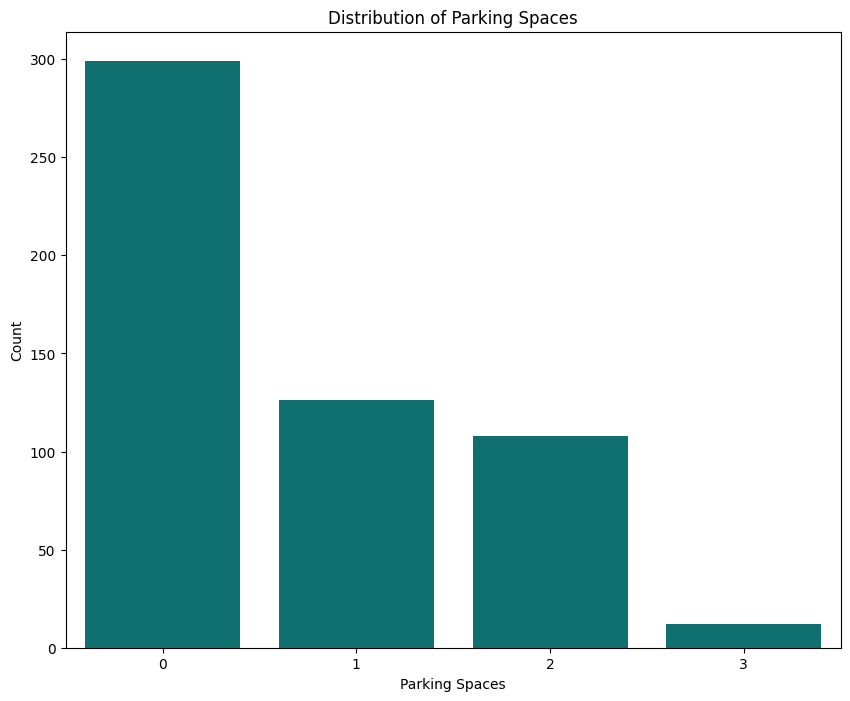

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="parking", data=Housing, color="teal")
plt.title("Distribution of Parking Spaces")
plt.xlabel("Parking Spaces")
plt.ylabel("Count")
plt.show()

### Summary of Univariate Analysis

From the univariate analysis, the following observations were made:

*   **Price:** The distribution of housing prices appears to be right-skewed, indicating that most houses are in the lower to mid-price range, with a few high-priced properties.
*   **Area:** Similar to price, the area distribution is also right-skewed, suggesting a majority of houses have smaller to medium-sized areas.
*   **Bedrooms, Bathrooms, Stories, Parking:** These discrete numerical variables show that 2-4 bedrooms, 1 bathroom, 1-2 stories, and 0-1 parking spaces are the most common configurations among the properties.
*   **Categorical Features (Furnishing Status, Mainroad, Guestroom, Basement, Hotwaterheating, Airconditioning, Prefarea):**
    *   Most houses are `semi-furnished` or `unfurnished`.
    *   A significant majority of houses have `mainroad` access.
    *   `Guestroom`, `basement`, `hotwaterheating`, `airconditioning`, and `prefarea` are less common features, with a majority of houses not possessing them. This suggests these might be differentiating features for higher-end properties.

In [ ]:
# To find
#  Which features have the highest variation?
#  Are there any outliers?
#  Which categories occur most frequently?

display(Housing.describe(include='all'))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN




*   **For Numerical Features (`price`, `area`, `bedrooms`, `bathrooms`, `stories`, `parking`):**
    *   **Variation**: `price` and `area` have the highest standard deviations, confirming their high variation.
    *   **Outliers**: from the `min`, `max`, `25%`, `50%` (median), and `75%` values. For `price` and `area`, the large difference between `75%` and `max` suggests potential right-skewed distributions and possible high-value outliers. For other features, the ranges look more contained.

*   **For Categorical Features (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, `furnishingstatus`):**
    *   **Most Frequent Categories**: The `top` row shows the most frequent category for each. For example, `mainroad`'s top value is `1` , and its `freq` is `468`, meaning 468 houses have main road access. Similarly, for `furnishingstatus`, the `top` is 'semi-furnished' with a `freq` of `227`.

Bivariate analysis

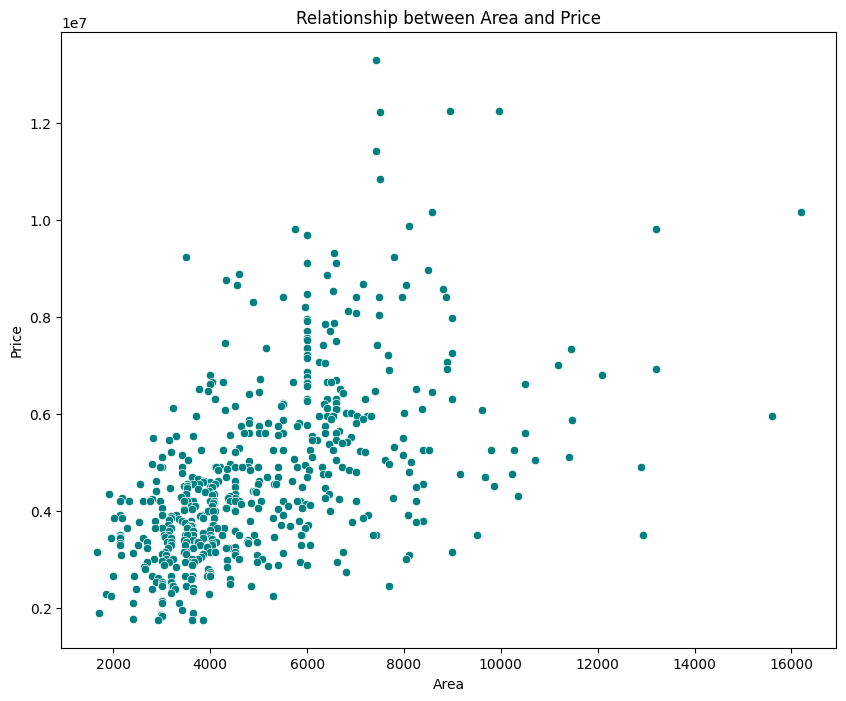

In [ ]:
#Bivariate analysis
plt.figure(figsize=(10,8))
sns.scatterplot(x="area", y="price", data=Housing, color="teal")
plt.title("Relationship between Area and Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

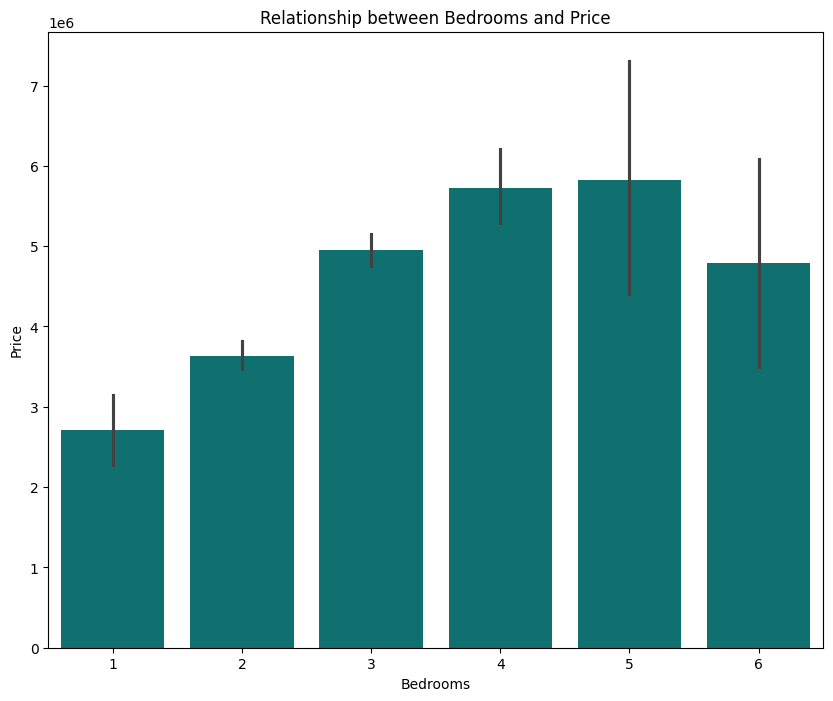

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x="bedrooms", y="price", data=Housing, color="teal")
plt.title("Relationship between Bedrooms and Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

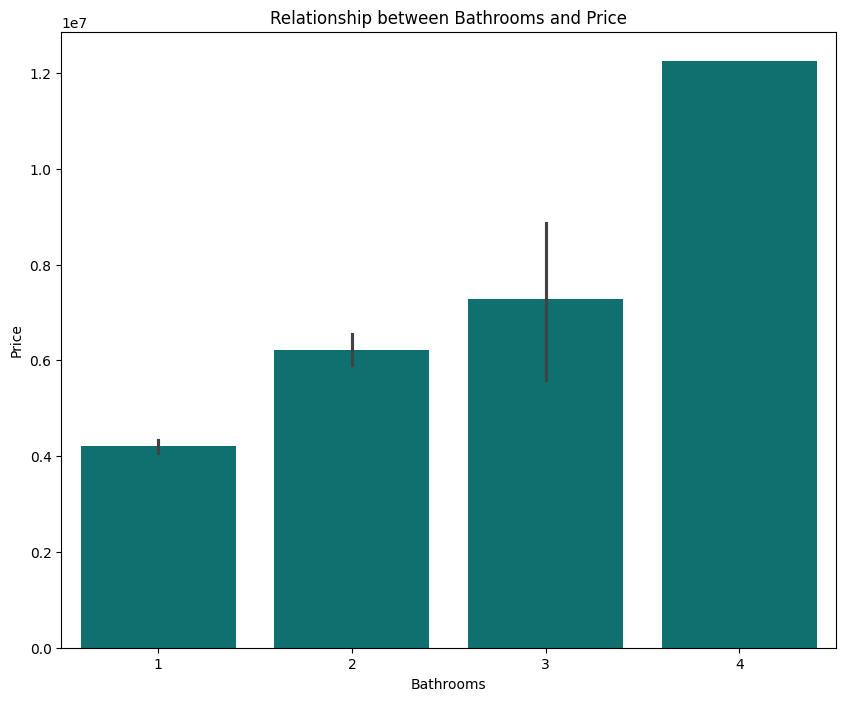

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x="bathrooms", y="price", data=Housing, color="teal")
plt.title("Relationship between Bathrooms and Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

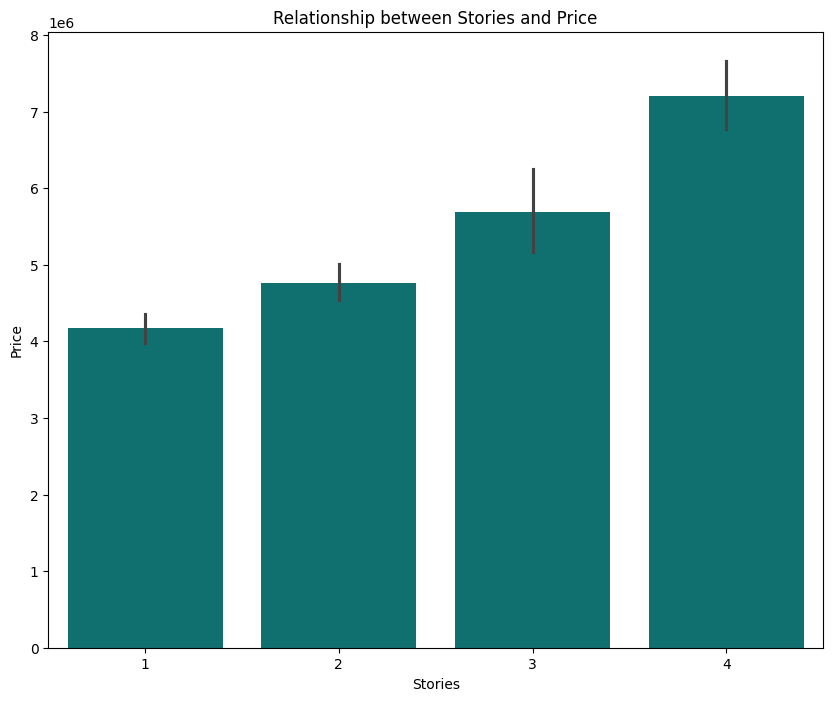

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x="stories", y="price", data=Housing, color="teal")
plt.title("Relationship between Stories and Price")
plt.xlabel("Stories")
plt.ylabel("Price")
plt.show()


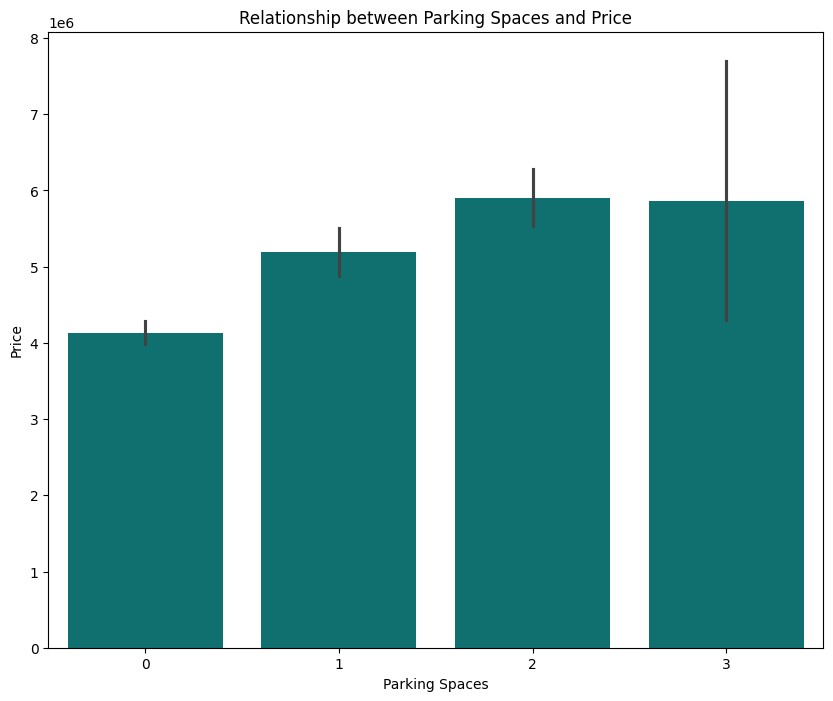

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x="parking", y="price", data=Housing, color="teal")
plt.title("Relationship between Parking Spaces and Price")
plt.xlabel("Parking Spaces")
plt.ylabel("Price")
plt.show()

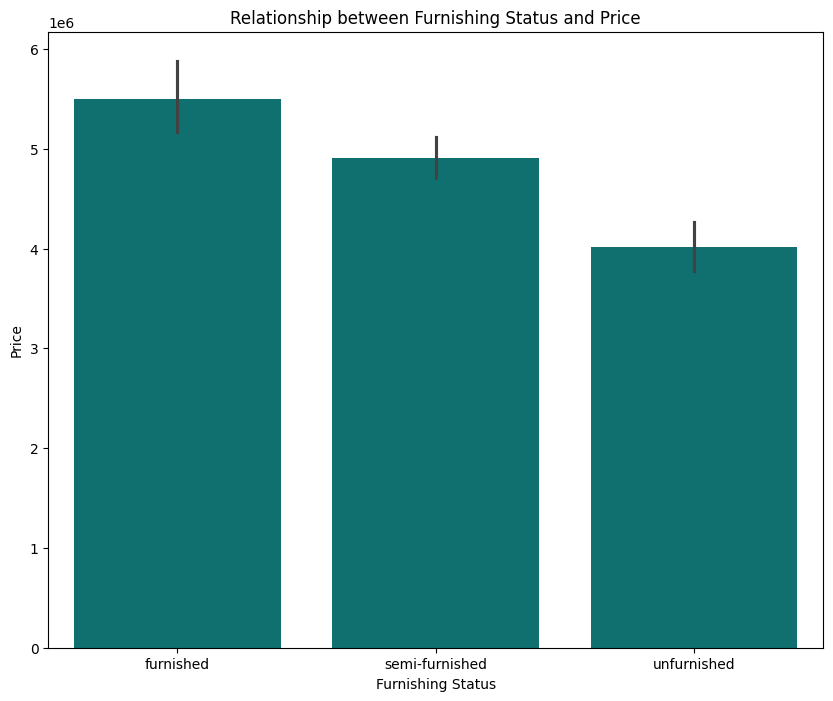

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x="furnishingstatus", y="price", data=Housing, color="teal")
plt.title("Relationship between Furnishing Status and Price")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

### Bivariate Analysis: Categorical Features vs. Price (Box Plots)

Box plots to visualize the distribution of  continuous variable (like `price`) across different categories of a categorical variable. to help understand how `price` varies based on features like `mainroad` access, `airconditioning`, etc.

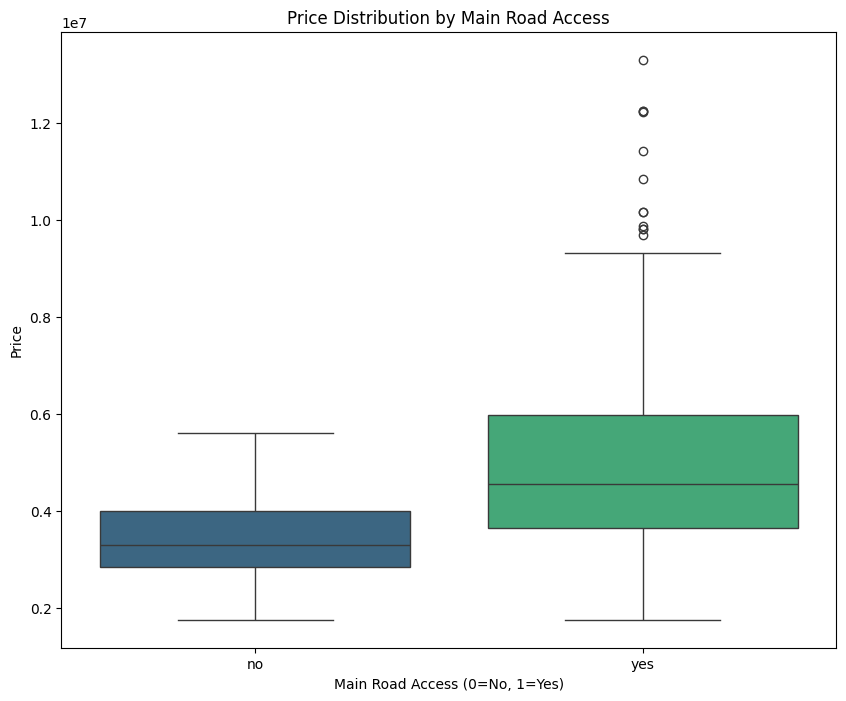

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='mainroad', y='price', data=Housing, hue='mainroad', palette='viridis', legend=False)
plt.title('Price Distribution by Main Road Access')
plt.xlabel('Main Road Access (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

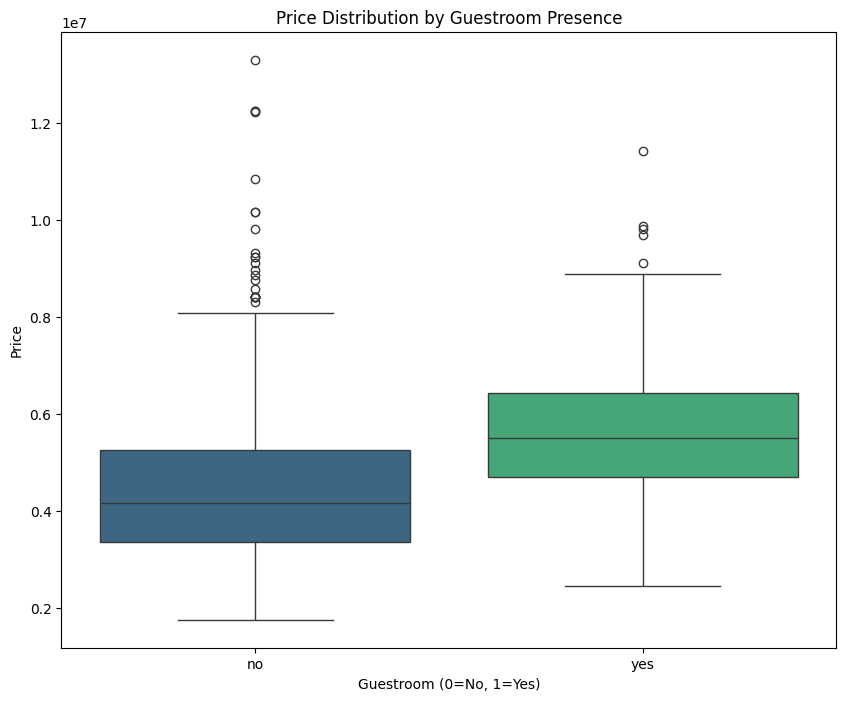

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='guestroom', y='price', data=Housing, hue='guestroom', palette='viridis', legend=False)
plt.title('Price Distribution by Guestroom Presence')
plt.xlabel('Guestroom (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

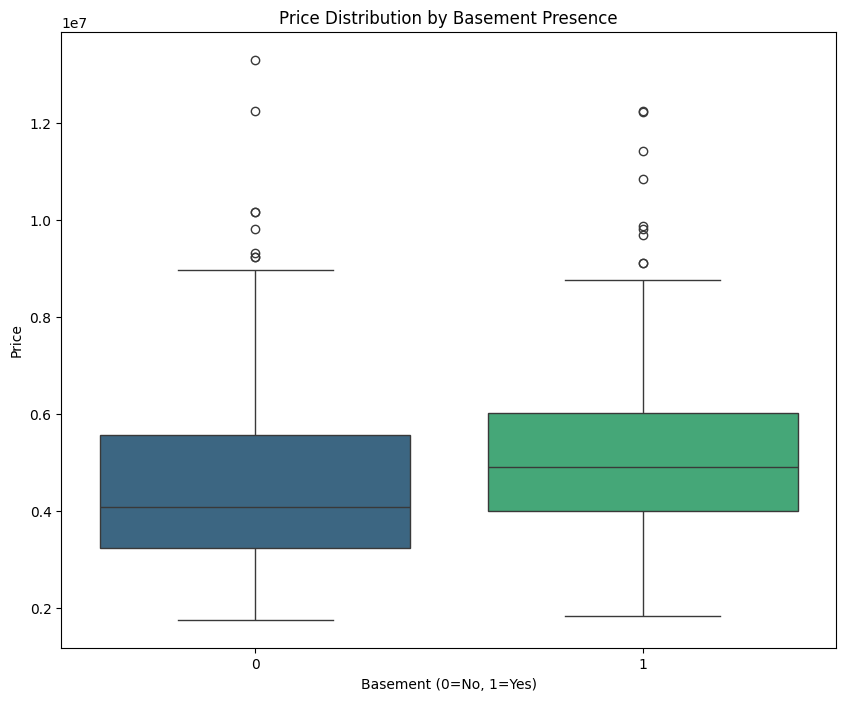

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='basement', y='price', data=Housing, hue='basement', palette='viridis', legend=False)
plt.title('Price Distribution by Basement Presence')
plt.xlabel('Basement (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

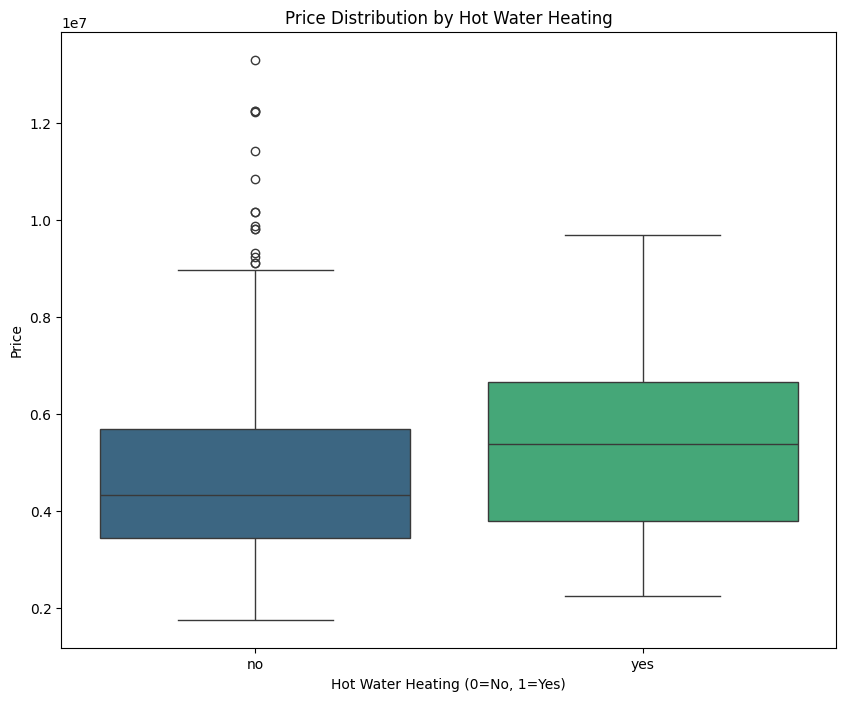

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='hotwaterheating', y='price', data=Housing, hue='hotwaterheating', palette='viridis', legend=False)
plt.title('Price Distribution by Hot Water Heating')
plt.xlabel('Hot Water Heating (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

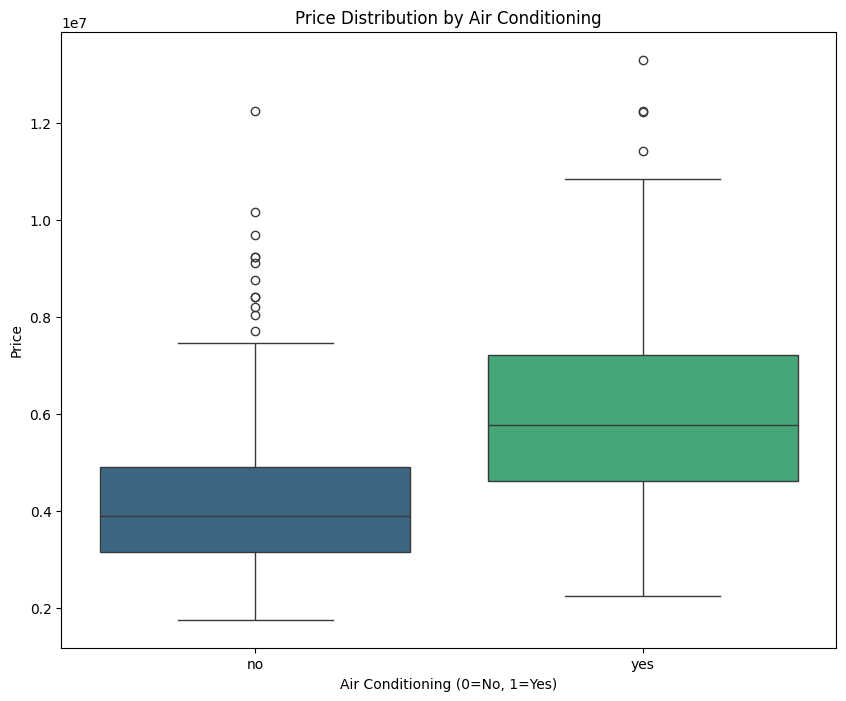

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='airconditioning', y='price', data=Housing, hue='airconditioning', palette='viridis', legend=False)
plt.title('Price Distribution by Air Conditioning')
plt.xlabel('Air Conditioning (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

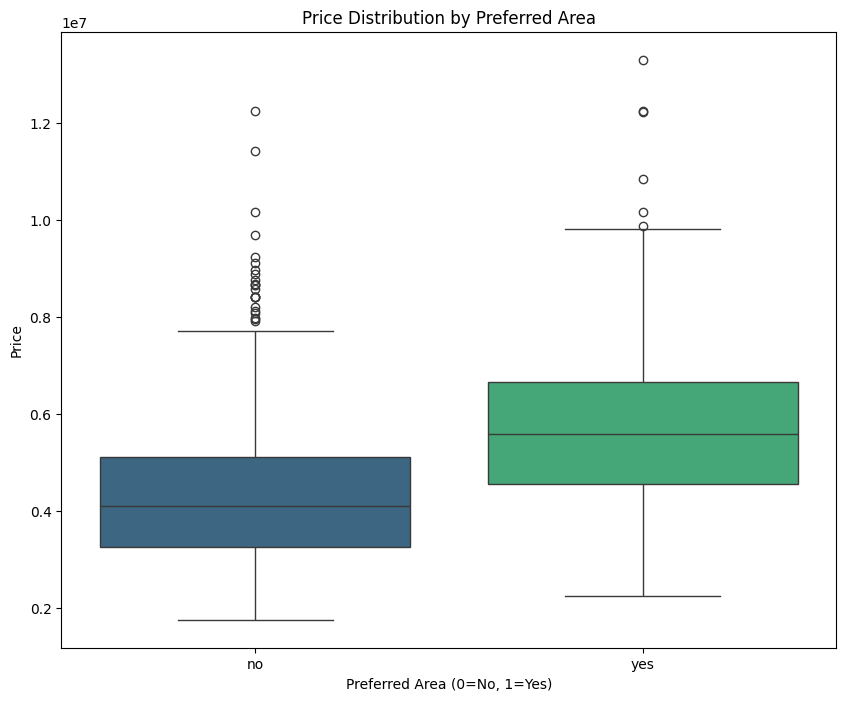

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='prefarea', y='price', data=Housing, hue='prefarea', palette='viridis', legend=False)
plt.title('Price Distribution by Preferred Area')
plt.xlabel('Preferred Area (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

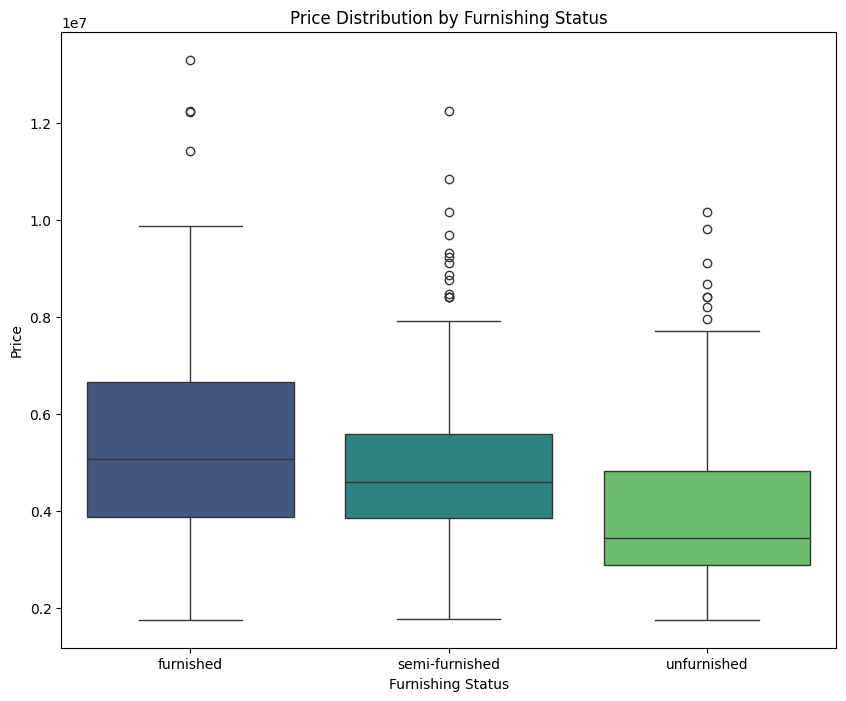

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='furnishingstatus', y='price', data=Housing, hue='furnishingstatus', palette='viridis', legend=False)
plt.title('Price Distribution by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Price')
plt.show()

### Summary of Bivariate Analysis

Bivariate analysis revealed several key relationships between features and `price`:

*   **Area vs. Price:** A strong positive linear relationship was observed, confirming that larger areas generally correspond to higher prices.
*   **Bedrooms, Bathrooms, Stories, Parking vs. Price (Bar Plots):** We saw a general trend where houses with more `bedrooms`, `bathrooms`, `stories`, and `parking` spaces tend to have higher average prices. The correlation, however, was not always perfectly linear for all categories, with some plateaus or slight drops at the highest ends.
*   **Categorical Features vs. Price (Box Plots):**
    *   Features like `mainroad` access, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, and `prefarea` all showed a positive impact on house prices. Houses possessing these features generally had significantly higher median prices and different price distributions compared to those without.
    *   `Airconditioning` and `prefarea` showed particularly strong positive associations with higher prices.
    *   `Furnishing status` clearly impacts price, with `furnished` homes generally having the highest prices, followed by `semi-furnished`, and then `unfurnished` homes.

### Encoding Binary Categorical Variables

To include binary categorical variables in correlation analysis, they need to be converted into numerical representations. map 'yes' to 1 and 'no' to 0 for relevant columns.

In [ ]:
# Define the list of binary categorical columns
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

# Map 'yes' to 1 and 'no' to 0 for these columns
for col in binary_cols:
    Housing[col] = Housing[col].map({'yes': 1, 'no': 0})

# Display the head of the DataFrame to show the changes
display(Housing.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


### One-Hot Encoding for 'furnishingstatus'

Applying one-hot encoding to the `furnishingstatus` column to convert its categories ('furnished', 'semi-furnished', 'unfurnished') into new binary columns, making them suitable for correlation analysis.

In [ ]:
Housing = pd.get_dummies(Housing, columns=['furnishingstatus'], drop_first=False)

# Display the head of the DataFrame to show the new columns
display(Housing.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [ ]:
# Convert boolean columns to integer (0 or 1) for correlation calculation
for col in Housing.select_dtypes(include='bool').columns:
    Housing[col] = Housing[col].astype(int)

# Calculate the correlation matrix with all numerical columns
all_numerical_cols = Housing.select_dtypes(include=np.number).columns
corr_matrix = Housing[all_numerical_cols].corr()

# Display the correlation matrix
display(corr_matrix)

,price,area,bedrooms,bathrooms,stories,parking,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394,0.229350,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980,0.145772,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270,0.079054,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496,0.108139,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547,0.093176,-0.003648,-0.082972
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000,0.131234,0.041327,-0.165705
furnishingstatus_furnished,0.229350,0.145772,0.079054,0.108139,0.093176,0.131234,1.000000,-0.496748,-0.409462
furnishingstatus_semi-furnished,0.063656,0.006156,0.050040,0.029834,-0.003648,0.041327,-0.496748,1.000000,-0.588405
furnishingstatus_unfurnished,-0.280587,-0.142278,-0.126252,-0.132107,-0.082972,-0.165705,-0.409462,-0.588405,1.000000


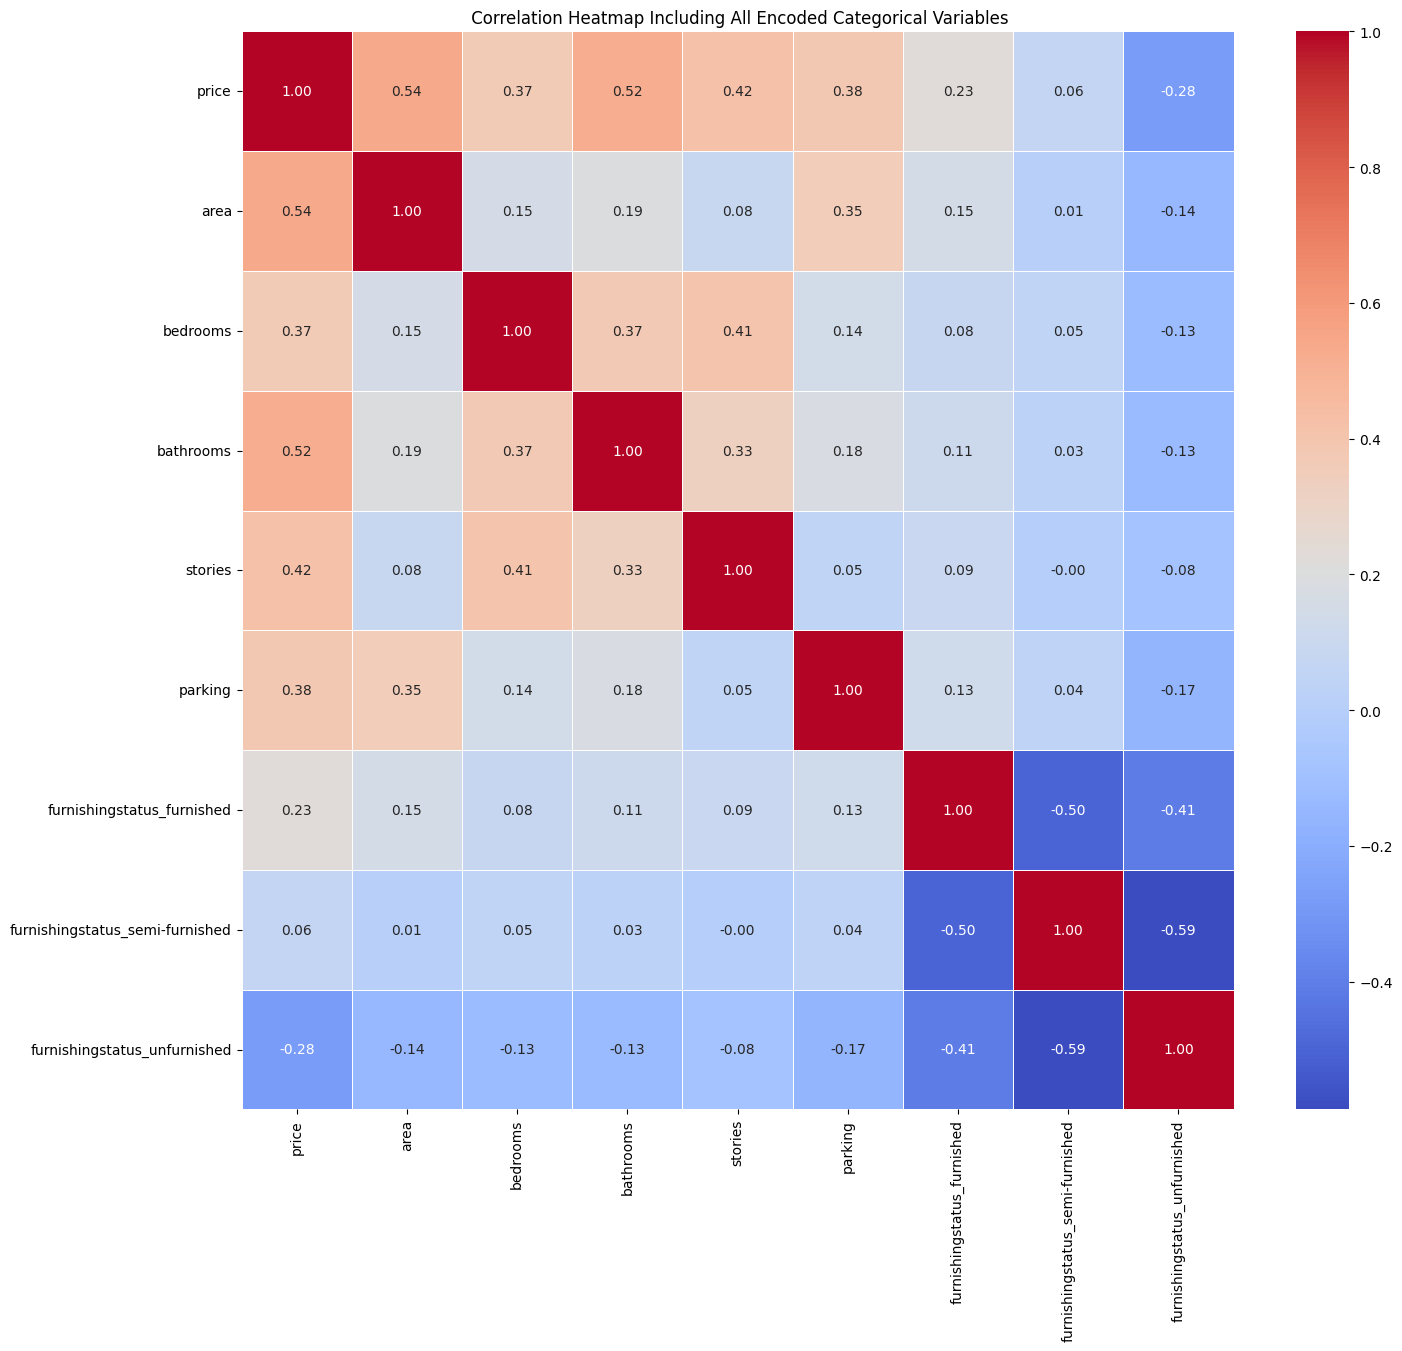

In [ ]:
# Generate the heatmap
plt.figure(figsize=(16, 14)) # Adjust figure size for more columns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(' Correlation Heatmap Including All Encoded Categorical Variables')
plt.show()

### Highly Correlated Variables and Important Features for ML Models

Based on the correlation matrix, the following features show a strong positive correlation with `price`:

*   **`area`**: Has the strongest positive correlation with `price` (0.54), indicating that larger areas generally lead to higher prices. This is a crucial feature for price prediction.
*   **`airconditioning`**: Shows a significant positive correlation with `price` (0.45). Houses with air conditioning tend to be more expensive.
*   **`bathrooms`**: Exhibits a strong positive correlation with `price` (0.52). More bathrooms are associated with higher prices.
*   **`stories`**: Moderately correlated with `price` (0.42). Houses with more stories tend to have higher prices.
*   **`parking`**: Moderately correlated with `price` (0.38). Properties with more parking spaces are generally more expensive.
*   **`prefarea`**: Shows a good positive correlation with `price` (0.33). Being in a preferred area increases the house price.
*   **`bedrooms`**: Moderately correlated with `price` (0.37). More bedrooms generally mean a higher price.
*   **`mainroad`**: Shows a moderate positive correlation with `price` (0.30). Access to a main road is a positive factor for price.
*   **`guestroom`**: Positively correlated with `price` (0.24). Homes with a guestroom tend to be more expensive.
*   **`basement`**: Positively correlated with `price` (0.19). A basement contributes positively to the price.
*   **`hotwaterheating`**: Shows a weak positive correlation with `price` (0.09). While positive, its impact is less pronounced compared to other features.

These features, particularly `area`, `bathrooms`, `airconditioning`, `stories`, `parking`, and `prefarea`, are strong candidates for inclusion in future machine learning models aimed at predicting housing prices due to their significant correlation with the target variable (`price`).